<a href="https://colab.research.google.com/github/RAJBIR-SINGH-NITT/AI-Bot--Smart-Auto-Reply-Bot/blob/main/Rajbir_SpiderML_BaseTask_BonusTask.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

RAJBIR_SPIDERML_BASETASK AND BONUS TASK

In [ ]:
# all imports at the top
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pickle


In [ ]:
# setting seed so results dont change every run
torch.manual_seed(42)


In [ ]:
# converting images to tensors and normalising them
# normalising to mean 0.5 std 0.5 so pixel values go from [0,1] to [-1,1]
# this helps gradients flow better during training
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])


In [ ]:
# downloading training data - train=True is important here
# i made the mistake of using train=False earlier which loads test set by mistake
full_train_dataset = datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)
print(f'training samples: {len(full_train_dataset)}')


100%|██████████| 26.4M/26.4M [00:01<00:00, 16.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 303kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.68MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 10.5MB/s]

training samples: 60000


In [ ]:
# downloading the test set separately
# i wont train on this, only use it at the end to make submission.csv
test_dataset = datasets.FashionMNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)
print(f'test samples: {len(test_dataset)}')


test samples: 10000


In [ ]:
# splitting training data into train and validation
# need a val set to track overfitting during training
# going with 50k train and 10k val
train_size = 50000
val_size   = 10000
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])
print(f'train: {len(train_dataset)} | val: {len(val_dataset)}')


train: 50000 | val: 10000


In [ ]:
# batch size 64 works well here - not too big not too small
# shuffle=True for training so model doesnt memorise the order
batch_size   = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)


In [ ]:
# quick check to make sure shapes are right before training
images, labels = next(iter(train_loader))
print(f'image batch shape: {images.shape}')
print(f'label batch shape: {labels.shape}')


image batch shape: torch.Size([64, 1, 28, 28])
label batch shape: torch.Size([64])


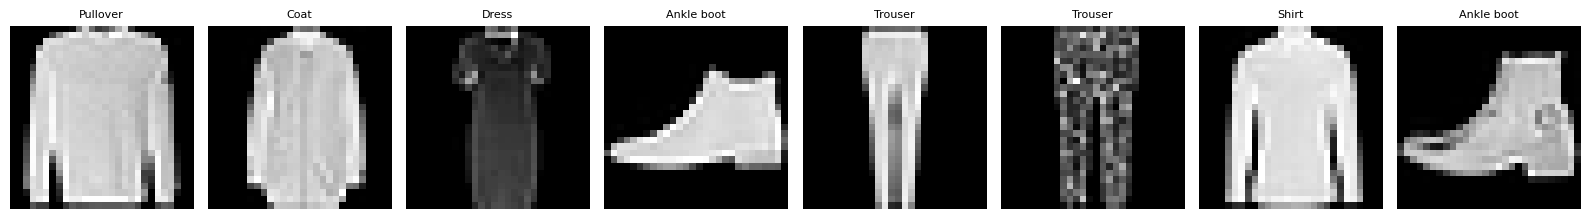

In [ ]:
# label mapping for visualisation
label_names = {
    0:'T-shirt/top', 1:'Trouser',  2:'Pullover', 3:'Dress',  4:'Coat',
    5:'Sandal',      6:'Shirt',    7:'Sneaker',  8:'Bag',    9:'Ankle boot'
}

# plotting first 8 images just to verify data loaded properly
fig, axes = plt.subplots(1, 8, figsize=(16, 3))
for i in range(8):
    img = images[i].squeeze().numpy()
    img = (img * 0.5) + 0.5  # undo normalisation just for display
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(label_names[labels[i].item()], fontsize=8)
    axes[i].axis('off')
plt.tight_layout()
plt.show()


In [ ]:
# building the model exactly as shown in the architecture diagram
# - main trunk: 784 - 16
# - left branch: 16 - 8 - 8 with skip connection
# - right branch: 16 - 12 - 8
# - concat both branches: 16 total - output 10 classes

class SpidyBranchingNet(nn.Module):
    def __init__(self):
        super(SpidyBranchingNet, self).__init__()

        # shared trunk layer - 784 inputs flattened from 28x28 image
        self.fc_trunk  = nn.Linear(784, 16)

        # left branch layers
        self.fc_left1  = nn.Linear(16, 8)
        self.fc_left2  = nn.Linear(8,  8)

        # right branch layers
        self.fc_right1 = nn.Linear(16, 12)
        self.fc_right2 = nn.Linear(12,  8)

        # final output - 16 merged features - 10 classes
        self.fc_output = nn.Linear(16, 10)


    def forward(self, x):
        # flatten (batch, 1, 28, 28) - (batch, 784)
        x = x.view(x.size(0), -1)

        # shared trunk
        x_trunk = F.relu(self.fc_trunk(x))

        # left branch
        out_left1 = F.relu(self.fc_left1(x_trunk))
        out_left2 = F.relu(self.fc_left2(out_left1))
        # skip connection - adds out_left1 back to preserve gradient flow
        left_branch_final = out_left2 + out_left1

        # right branch - no skip connection here, dimensions dont match
        out_right1 = F.relu(self.fc_right1(x_trunk))
        out_right2 = F.relu(self.fc_right2(out_right1))
        right_branch_final = out_right2

        # concatenate both branches along feature dim - (batch, 16)
        merged = torch.cat((left_branch_final, right_branch_final), dim=1)

        # output logits
        logits = self.fc_output(merged)
        return logits


# dry run to check dimensions before training
model = SpidyBranchingNet()
print(model)
dummy = torch.randn(2, 1, 28, 28)
print(f'output shape: {model(dummy).shape}')


SpidyBranchingNet(
  (fc_trunk): Linear(in_features=784, out_features=16, bias=True)
  (fc_left1): Linear(in_features=16, out_features=8, bias=True)
  (fc_left2): Linear(in_features=8, out_features=8, bias=True)
  (fc_right1): Linear(in_features=16, out_features=12, bias=True)
  (fc_right2): Linear(in_features=12, out_features=8, bias=True)
  (fc_output): Linear(in_features=16, out_features=10, bias=True)
)
output shape: torch.Size([2, 10])


In [ ]:
# using gpu if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'device: {device}')

model = SpidyBranchingNet().to(device)

# crossentropy handles softmax internally so i return raw logits from model
criterion = nn.CrossEntropyLoss()

# adam with lr 0.001 standard starting point for classification
optimizer = optim.Adam(model.parameters(), lr=0.001)

# lists to store metrics for plotting
train_losses, val_losses         = [], []
train_accuracies, val_accuracies = [], []

EPOCHS = 10


device: cpu


In [ ]:
print('starting training\n')

for epoch in range(EPOCHS):

    # training time
    model.train()
    running_loss  = 0.0
    correct_train = 0
    total_train   = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        # zero grad because pytorch accumulates gradients by default
        optimizer.zero_grad()

        outputs = model(images)
        loss    = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss  += loss.item() * images.size(0)
        _, predicted   = torch.max(outputs.data, 1)
        total_train   += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_train_loss = running_loss / len(train_loader.dataset)
    epoch_train_acc  = (correct_train / total_train) * 100

    # validation time
    model.eval()
    running_val_loss = 0.0
    correct_val      = 0
    total_val        = 0

    # no_grad saves memory since we dont need gradients during validation
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss    = criterion(outputs, labels)

            running_val_loss += loss.item() * images.size(0)
            _, predicted      = torch.max(outputs.data, 1)
            total_val        += labels.size(0)
            correct_val      += (predicted == labels).sum().item()

    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    epoch_val_acc  = (correct_val / total_val) * 100

    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    train_accuracies.append(epoch_train_acc)
    val_accuracies.append(epoch_val_acc)

    print(f'Epoch [{epoch+1}/{EPOCHS}] - '
          f'train loss: {epoch_train_loss:.4f}  train acc: {epoch_train_acc:.2f}% -'
          f'val loss: {epoch_val_loss:.4f}  val acc: {epoch_val_acc:.2f}%')


starting training

Epoch [1/10] -- train loss: 0.7668  train acc: 72.30% -- val loss: 0.5168  val acc: 81.00%
Epoch [2/10] -- train loss: 0.4680  train acc: 83.25% -- val loss: 0.4568  val acc: 83.48%
Epoch [3/10] -- train loss: 0.4339  train acc: 84.43% -- val loss: 0.4320  val acc: 84.91%
Epoch [4/10] -- train loss: 0.4117  train acc: 85.29% -- val loss: 0.4265  val acc: 84.76%
Epoch [5/10] -- train loss: 0.4003  train acc: 85.56% -- val loss: 0.4068  val acc: 85.55%
Epoch [6/10] -- train loss: 0.3870  train acc: 86.02% -- val loss: 0.4119  val acc: 85.14%
Epoch [7/10] -- train loss: 0.3810  train acc: 86.20% -- val loss: 0.4190  val acc: 84.97%
Epoch [8/10] -- train loss: 0.3702  train acc: 86.64% -- val loss: 0.4031  val acc: 85.52%
Epoch [9/10] -- train loss: 0.3642  train acc: 86.83% -- val loss: 0.3936  val acc: 85.58%
Epoch [10/10] -- train loss: 0.3578  train acc: 87.02% -- val loss: 0.3888  val acc: 86.12%


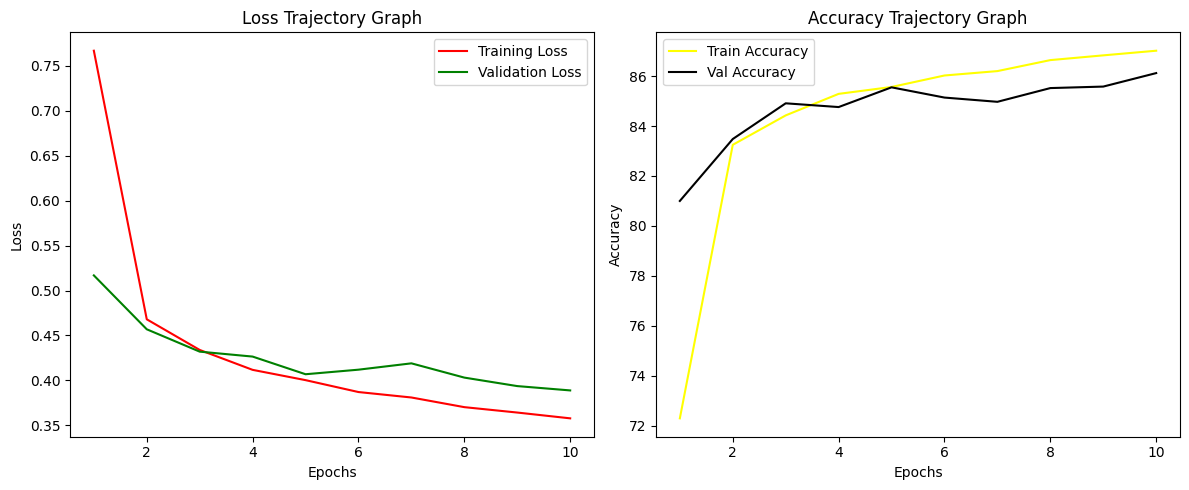

In [ ]:
# plotting loss and accuracy curves
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, len(train_losses)+1), train_losses, label='Training Loss',   color='red')
plt.plot(range(1, len(val_losses)+1),   val_losses,   label='Validation Loss', color='green')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss Trajectory Graph')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, len(train_accuracies)+1), train_accuracies, label='Train Accuracy', color='yellow')
plt.plot(range(1, len(val_accuracies)+1),   val_accuracies,   label='Val Accuracy',   color='black')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy Trajectory Graph')
plt.legend()

plt.tight_layout()
plt.savefig('training_plots.png', dpi=150)
plt.show()


In [ ]:
# saving model weights using pickle as required by the task
with open('spidy_model_weights.pkl', 'wb') as f:
    pickle.dump(model.state_dict(), f)
print('model weights saved to spidy_model_weights.pkl')


model weights saved to spidy_model_weights.pkl


In [ ]:
# generating predictions on test set for submission.csv
model.eval()
test_predictions = []

with torch.no_grad():
    for images, _ in test_loader:
        images   = images.to(device)
        outputs  = model(images)
        _, predicted = torch.max(outputs, 1)
        test_predictions.extend(predicted.cpu().numpy())

submission_df = pd.DataFrame({
    'Index': range(len(test_predictions)),
    'label': test_predictions
})
submission_df.to_csv('submission.csv', index=False)
print('submission.csv created')
print(submission_df.head())


submission.csv created
   Index  label
0      0      9
1      1      2
2      2      1
3      3      1
4      4      6


Bonus Task (Autoencoder)


In [ ]:
# implementing a fully connected autoencoder on fashion-mnist
# idea: compress 784 pixels into a small latent vector, then reconstruct
# going to try 3 different latent sizes to see how it affects quality

class FashionAutoencoder(nn.Module):
    def __init__(self, latent_dim=32):
        super(FashionAutoencoder, self).__init__()

        # encoder -- compress down to latent_dim
        self.encoder = nn.Sequential(
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim),
            nn.ReLU()
        )

        # decoder -- reconstruct back to 784
        # sigmoid at end because pixel values should be in [0,1]
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 784),
            nn.Sigmoid()
        )

    def forward(self, x):
        x             = x.view(x.size(0), -1)
        latent        = self.encoder(x)
        reconstructed = self.decoder(latent)
        return reconstructed.view(x.size(0), 1, 28, 28)


print('autoencoder class defined')


autoencoder class defined


In [ ]:
# training 3 autoencoders with different latent sizes
# using MSELoss -- measures pixel-level reconstruction error

AE_EPOCHS        = 10
latent_sizes     = [64, 32, 16]
trained_aes      = {}
ae_loss_history  = {}

ae_loader = DataLoader(full_train_dataset, batch_size=128, shuffle=True)

for latent_dim in latent_sizes:
    print(f'\ntraining autoencoder -- latent_dim={latent_dim}')

    ae      = FashionAutoencoder(latent_dim=latent_dim).to(device)
    ae_opt  = optim.Adam(ae.parameters(), lr=0.001)
    ae_loss = nn.MSELoss()
    losses  = []

    for epoch in range(AE_EPOCHS):
        ae.train()
        total_loss = 0.0

        for images, _ in ae_loader:
            images = images.to(device)
            ae_opt.zero_grad()

            recon = ae(images)

            # unnormalize original to [0,1] to match sigmoid output
            original = (images * 0.5) + 0.5

            loss = ae_loss(recon, original)
            loss.backward()
            ae_opt.step()
            total_loss += loss.item() * images.size(0)

        avg_loss = total_loss / len(ae_loader.dataset)
        losses.append(avg_loss)
        print(f'  epoch [{epoch+1}/{AE_EPOCHS}]  loss: {avg_loss:.6f}')

    trained_aes[latent_dim]     = ae
    ae_loss_history[latent_dim] = losses

print('\ndone training all 3 autoencoders')



training autoencoder -- latent_dim=64
  epoch [1/10]  loss: 0.031341
  epoch [2/10]  loss: 0.017244
  epoch [3/10]  loss: 0.014879
  epoch [4/10]  loss: 0.013455
  epoch [5/10]  loss: 0.012478
  epoch [6/10]  loss: 0.011744
  epoch [7/10]  loss: 0.011181
  epoch [8/10]  loss: 0.010720
  epoch [9/10]  loss: 0.010356
  epoch [10/10]  loss: 0.010042

training autoencoder -- latent_dim=32
  epoch [1/10]  loss: 0.031865
  epoch [2/10]  loss: 0.017403
  epoch [3/10]  loss: 0.015098
  epoch [4/10]  loss: 0.013725
  epoch [5/10]  loss: 0.012796
  epoch [6/10]  loss: 0.012171
  epoch [7/10]  loss: 0.011750
  epoch [8/10]  loss: 0.011453
  epoch [9/10]  loss: 0.011163
  epoch [10/10]  loss: 0.010931

training autoencoder -- latent_dim=16
  epoch [1/10]  loss: 0.033003
  epoch [2/10]  loss: 0.018052
  epoch [3/10]  loss: 0.015985
  epoch [4/10]  loss: 0.014863
  epoch [5/10]  loss: 0.014135
  epoch [6/10]  loss: 0.013590
  epoch [7/10]  loss: 0.013206
  epoch [8/10]  loss: 0.012901
  epoch [9/10

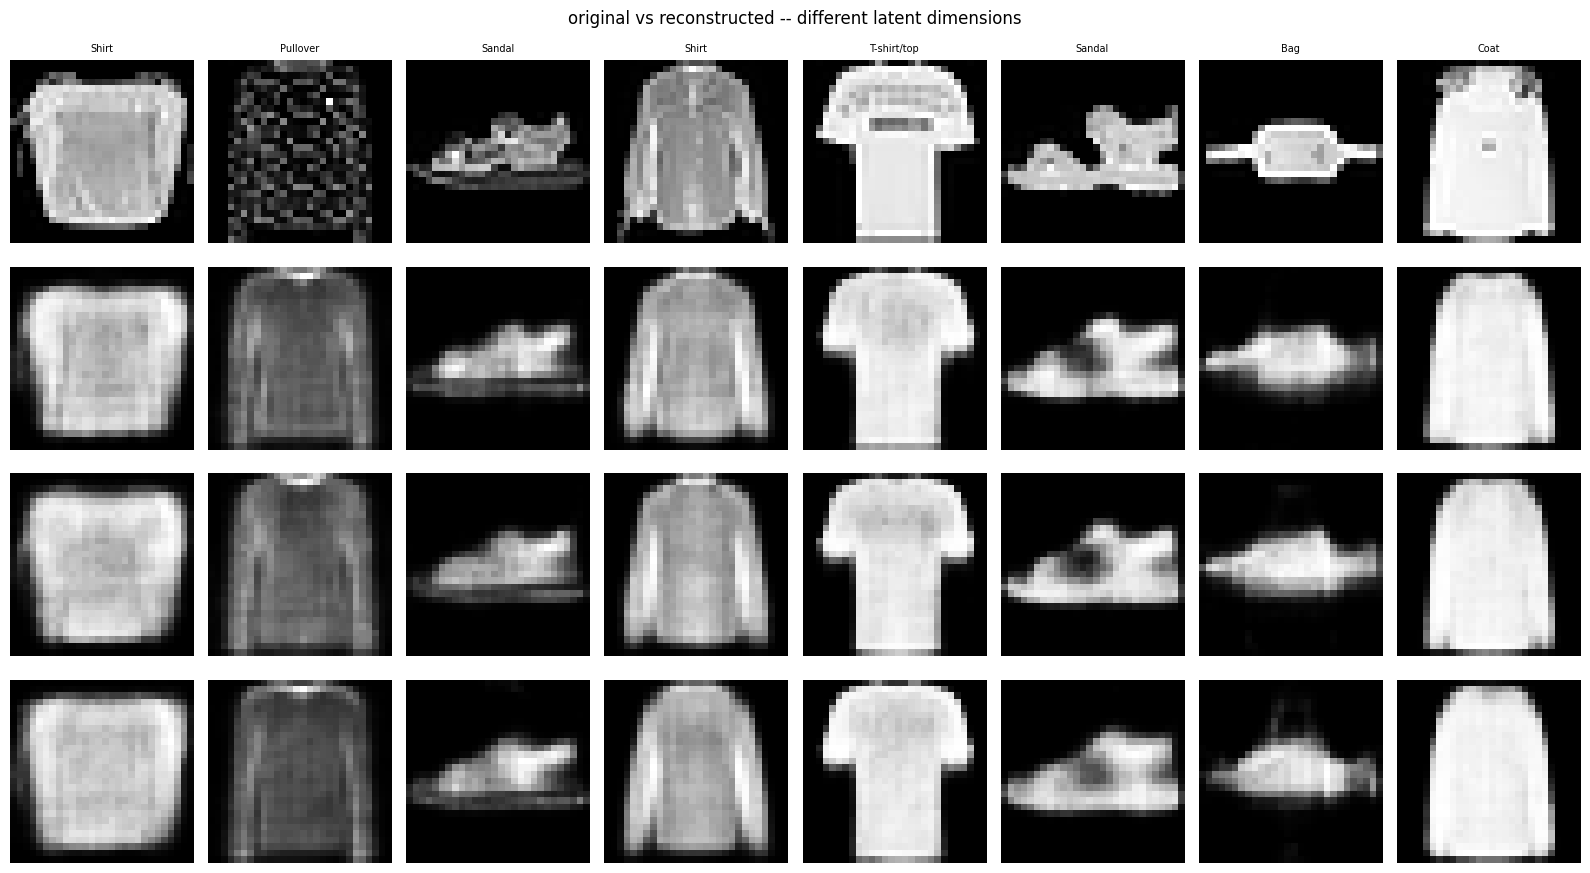

In [ ]:
# comparing original vs reconstructed images side by side
# row 0 = original, row 1 = latent64, row 2 = latent32, row 3 = latent16

sample_imgs, sample_lbls = next(iter(DataLoader(test_dataset, batch_size=8, shuffle=True)))

fig, axes = plt.subplots(4, 8, figsize=(16, 9))

# original row
for col in range(8):
    img = (sample_imgs[col].squeeze().numpy() * 0.5) + 0.5
    axes[0, col].imshow(img, cmap='gray')
    axes[0, col].set_title(label_names[sample_lbls[col].item()], fontsize=7)
    axes[0, col].axis('off')
axes[0, 0].set_ylabel('original', fontsize=9)

# reconstructed rows
for row, latent_dim in enumerate(latent_sizes, start=1):
    ae = trained_aes[latent_dim]
    ae.eval()
    with torch.no_grad():
        recon = ae(sample_imgs.to(device)).cpu()
    for col in range(8):
        img = np.clip(recon[col].squeeze().numpy(), 0, 1)
        axes[row, col].imshow(img, cmap='gray')
        axes[row, col].axis('off')
    axes[row, 0].set_ylabel(f'latent={latent_dim}', fontsize=9)

plt.suptitle('original vs reconstructed -- different latent dimensions')
plt.tight_layout()
plt.savefig('autoencoder_reconstructions.png', dpi=150)
plt.show()


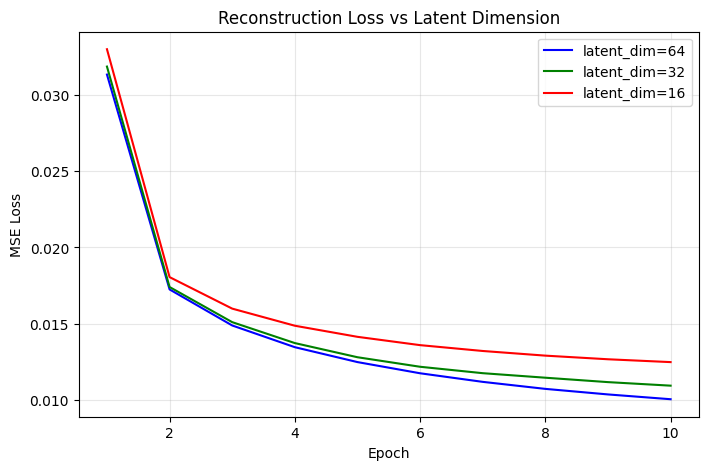

In [ ]:
# plotting reconstruction loss for all 3 latent sizes
plt.figure(figsize=(8, 5))
colors = {64: 'blue', 32: 'green', 16: 'red'}
for latent_dim, losses in ae_loss_history.items():
    plt.plot(range(1, AE_EPOCHS+1), losses, label=f'latent_dim={latent_dim}', color=colors[latent_dim])
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Reconstruction Loss vs Latent Dimension')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('autoencoder_loss_comparison.png', dpi=150)
plt.show()


In [ ]:
# checking all output files are there
import os
files = ['spidy_model_weights.pkl', 'submission.csv',
         'training_plots.png', 'autoencoder_reconstructions.png', 'autoencoder_loss_comparison.png']
for f in files:
    status = 'ok' if os.path.exists(f) else 'missing'
    print(f'{f} -- {status}')


spidy_model_weights.pkl -- ok
submission.csv -- ok
training_plots.png -- ok
autoencoder_reconstructions.png -- ok
autoencoder_loss_comparison.png -- ok
